# 第二部分 2.3：监督学习

| 章节 | 内容 |
|------|------|
| **2.5 线性模型** | 回归（线性/Ridge/Lasso/多项式）、分类（逻辑回归）|
| **2.6 树模型** | 决策树、随机森林、集成学习（AdaBoost / GBDT）|
| **2.7 K 近邻（KNN）** | 懒惰学习、K 值选择、距离度量、维度诅咒 |
| **2.8 支持向量机** | 硬间隔、软间隔、核函数 |
| **2.9 模型评估** | 分类评估（混淆矩阵/F1/ROC-AUC）、回归评估（MAE/RMSE/R²）|

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification, make_regression, make_blobs, make_moons
from sklearn.model_selection import train_test_split

matplotlib.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
print('环境就绪')

环境就绪


## 监督学习概览

监督学习的「分类方式」有两个维度，容易混淆：

### 维度一：按任务类型分（预测目标是什么）

| 任务 | 预测目标 | 典型例子 |
|------|----------|----------|
| **回归（Regression）** | 连续值 | 房价预测、温度预测、销量预测 |
| **分类（Classification）** | 离散标签 | 垃圾邮件判断、猫狗识别、信用评估 |

### 维度二：按模型族分（用什么结构的模型）

| 模型族 | 数学结构 | 能做回归？ | 能做分类？ |
|--------|----------|-----------|-----------|
| **线性模型** | 输出 = 特征的线性组合 | ✅ 线性回归、Ridge、Lasso | ✅ 逻辑回归 |
| **树模型** | 递归二分特征空间 | ✅ 回归树、随机森林回归 | ✅ 分类树、随机森林分类 |
| **支持向量机** | 最大化间隔超平面 | ✅ SVR | ✅ SVC |

> **关键认知**：两个维度互相独立。「线性模型」描述的是模型的数学结构，不是任务类型——线性模型既能做回归（线性回归），也能做分类（逻辑回归）。后续 2.5~2.7 均按**模型族**组织，每节内部再区分回归与分类用法。

## 2.5 线性模型

线性模型假设输出是输入特征的线性组合，是最简单也最常用的一类模型。优点：**可解释性强、训练快、可作为 baseline**。

---

### 用于回归任务

#### 线性回归（Linear Regression）

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b$$

训练目标：最小化均方误差 $\text{MSE} = \frac{1}{n}\sum(y_i - \hat{y}_i)^2$

**单输出 vs 多输出**：需要同时预测多个目标值时（如温度、湿度、气压），变为**多输出回归**，权重矩阵 $W$ 变为 $m \times d$，$\hat{\mathbf{y}}$ 变为 $m$ 维向量。神经网络的每一个线性层本质上就是这个多输出形式。

#### 扩展到非线性：多项式回归

线性模型本身只能拟合直线。通过**特征工程**可以让它拟合曲线——把原始特征 $x$ 替换为一组新特征：

$$x \;\longrightarrow\; [x,\; x^2,\; x^3,\; \ldots]$$

然后对这组新特征做普通线性回归，得到**多项式回归**：

$$\hat{y} = w_1 x + w_2 x^2 + w_3 x^3 + b$$

**为什么明明有 $x^2$、$x^3$，还说"对参数是线性的"？**

关键在于：**"线性"描述的是 $\hat{y}$ 对权重 $w$ 的关系，不是对 $x$ 的关系。**

换一个视角——把 $x^2$ 和 $x^3$ 看作已经计算好的新特征，重新命名：

$$z_1 = x, \quad z_2 = x^2, \quad z_3 = x^3$$

模型变成：

$$\hat{y} = w_1 z_1 + w_2 z_2 + w_3 z_3 + b$$

这就是标准的线性回归形式——$w$ 都只以一次方出现，没有 $w^2$，没有 $w_1 \cdot w_2$，也没有 $e^w$。

训练时求解的正是这些 $w$，而 $z_1, z_2, z_3$ 是已知的输入数据，不是要优化的对象。所以从**优化角度**看，多项式回归和线性回归完全一样：同样可以用最小二乘法解析求解，同样可以用梯度下降，计算复杂度没有区别。

> **类比**：你去超市买水果，苹果 1 个、橙子 2 个、香蕉 3 个，要算总价。苹果价格、橙子价格、香蕉价格是"参数"（你要求的），个数是"特征"（已知）。不管个数是 1、2 还是 3 的平方，算总价的方式都是线性叠加。

非线性模型是指 $w$ 本身以非线性方式出现，例如 $\hat{y} = e^{w_1 x}$——这时就无法用线性代数方法直接求解了。

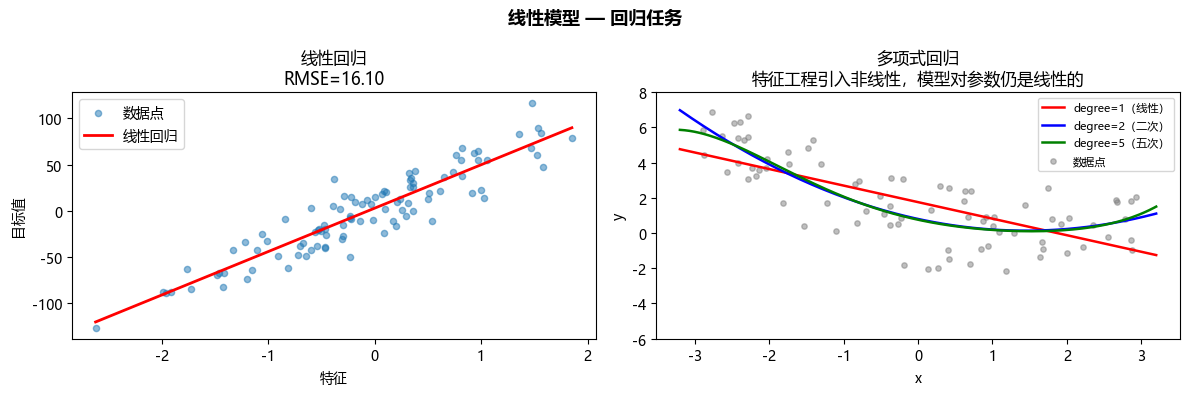

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('线性模型 — 回归任务', fontsize=13, fontweight='bold')

# ── 图1：线性回归 ─────────────────────────────────────────────
X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=20)
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2)
lr = LinearRegression().fit(X_tr, y_tr)
rmse = np.sqrt(mean_squared_error(y_te, lr.predict(X_te)))

x_line = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
axes[0].scatter(X_reg, y_reg, alpha=0.5, s=20, label='数据点')
axes[0].plot(x_line, lr.predict(x_line), 'r-', lw=2, label='线性回归')
axes[0].set_title(f'线性回归\nRMSE={rmse:.2f}')
axes[0].set_xlabel('特征')
axes[0].set_ylabel('目标值')
axes[0].legend()

# ── 图2：多项式回归（特征工程引入非线性） ────────────────────
np.random.seed(0)
X_poly = np.sort(np.random.uniform(-3, 3, 80))
y_poly = 0.5 * X_poly**2 - X_poly + np.random.randn(80) * 1.5
X_p = X_poly.reshape(-1, 1)

x_plot = np.linspace(-3.2, 3.2, 200).reshape(-1, 1)
for deg, color, label in [(1, 'red', 'degree=1（线性）'),
                           (2, 'blue', 'degree=2（二次）'),
                           (5, 'green', 'degree=5（五次）')]:
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(X_p, y_poly)
    axes[1].plot(x_plot, model.predict(x_plot), color=color, lw=1.8, label=label)
axes[1].scatter(X_poly, y_poly, s=15, alpha=0.5, color='gray', label='数据点')
axes[1].set_title('多项式回归\n特征工程引入非线性，模型对参数仍是线性的')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend(fontsize=8)
axes[1].set_ylim(-6, 8)

plt.tight_layout()
plt.show()


### 用于分类任务

#### 逻辑回归（Logistic Regression）

名字里有"回归"，但它是**分类**模型。在线性输出上套一个 Sigmoid 函数，将结果压缩到 (0, 1) 作为概率：

$$P(y=1|\mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1+e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

训练目标：最小化**交叉熵损失**（等价于最大化对数似然）。

决策边界是特征空间中的一条**线性超平面**（2D 下是直线）。

> 模型输出的是**概率**（连续值），把概率 > 0.5 判为正类是人为加的后处理，不是模型本身。

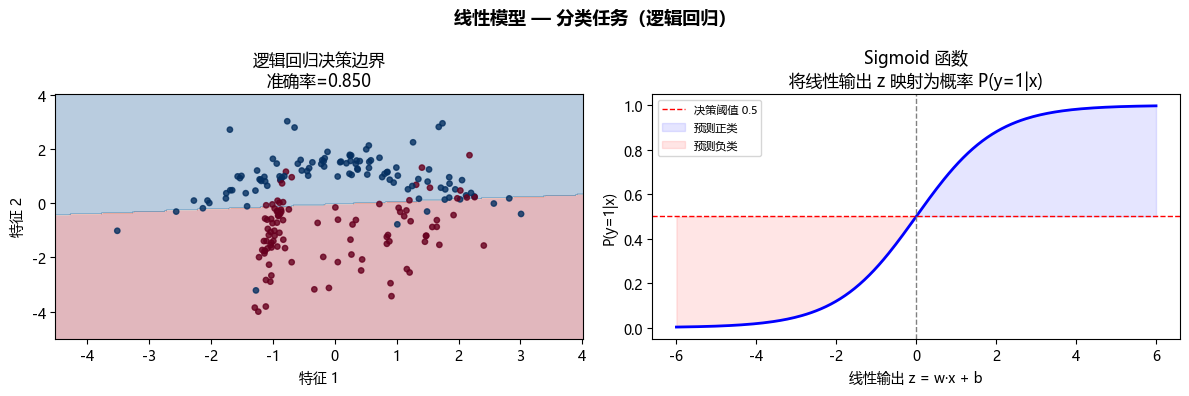

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('线性模型 — 分类任务（逻辑回归）', fontsize=13, fontweight='bold')

# ── 图1：逻辑回归决策边界 ─────────────────────────────────────
X_cls, y_cls = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                   n_informative=2, random_state=1)
X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls, test_size=0.2)
log_reg = LogisticRegression().fit(X_tr, y_tr)
acc = accuracy_score(y_te, log_reg.predict(X_te))

xx, yy = np.meshgrid(np.linspace(X_cls[:, 0].min() - 1, X_cls[:, 0].max() + 1, 200),
                     np.linspace(X_cls[:, 1].min() - 1, X_cls[:, 1].max() + 1, 200))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
axes[0].scatter(X_cls[:, 0], X_cls[:, 1], c=y_cls, cmap='RdBu', s=15, alpha=0.8)
axes[0].set_title(f'逻辑回归决策边界\n准确率={acc:.3f}')
axes[0].set_xlabel('特征 1')
axes[0].set_ylabel('特征 2')

# ── 图2：Sigmoid 函数 ─────────────────────────────────────────
z = np.linspace(-6, 6, 200)
sigmoid = 1 / (1 + np.exp(-z))
axes[1].plot(z, sigmoid, 'b-', lw=2)
axes[1].axhline(0.5, color='r', linestyle='--', lw=1, label='决策阈值 0.5')
axes[1].axvline(0, color='gray', linestyle='--', lw=1)
axes[1].fill_between(z, sigmoid, 0.5, where=(sigmoid > 0.5), alpha=0.1, color='blue', label='预测正类')
axes[1].fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.1, color='red', label='预测负类')
axes[1].set_title('Sigmoid 函数\n将线性输出 z 映射为概率 P(y=1|x)')
axes[1].set_xlabel('线性输出 z = w·x + b')
axes[1].set_ylabel('P(y=1|x)')
axes[1].legend(fontsize=8)
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()


## 2.6 树模型与集成学习

**决策树**是本节的基础学习器（base learner）。在此之上，**集成学习（Ensemble Learning）** 通过组合多个弱学习器来提升性能——基础学习器理论上可以是任何模型（SVM、逻辑回归等），本节选用决策树，因为它足够直观，且随机森林、XGBoost 等主流集成方法都以决策树为基础。

本节介绍三类模型：
- **单棵决策树**：基础，直观，容易过拟合
- **Bagging 集成（随机森林）**：并行训练多棵树，投票降低方差
- **Boosting 集成（AdaBoost / XGBoost）**：串行训练，逐步纠错

> 随机森林和 XGBoost 的本质是集成学习方法，之所以放在本节，是因为它们的基础学习器都是决策树。

---

### 实战数据集：Titanic 乘客生存预测

本节使用 seaborn 内置的 **泰坦尼克号乘客数据集** 贯穿所有模型对比。

| 属性 | 说明 |
|------|------|
| **来源** | 1912 年泰坦尼克号沉船事故乘客记录 |
| **规模** | 891 个样本，7 个特征 |
| **任务** | 二分类：存活（1）/ 遇难（0） |
| **类别比例** | 遇难 549（62%）/ 存活 342（38%），轻度不平衡 |
| **特征内容** | 船舱等级（pclass）、性别（sex）、年龄（age）、兄弟配偶数（sibsp）、父母子女数（parch）、票价（fare）、登船港口（embarked） |

**为什么选这个数据集？**
- seaborn 直接内置，一行加载，无需下载
- 特征含义直观，决策树的分裂规则完全符合常识（"女士优先"、头等舱优先逃生）
- 混合了连续特征（年龄、票价）和类别特征（性别、港口），贴近真实场景

---

### 决策树

每次从所有特征中选出**最优的切分特征和切分点**，把当前节点的样本一分为二，递归向下，直到叶节点只剩一种类别（分类）或方差足够小（回归）。

深度越深 → 模型越复杂 → 越容易过拟合。常用 `max_depth`、`min_samples_leaf` 限制树的生长。

#### 三种主流算法：ID3 → C4.5 → CART

决策树的核心问题是**如何选最优分裂特征**，三种算法代表了历史演进：

| 算法 | 分裂准则 | 主要特点 |
|------|---------|---------|
| **ID3**（1986） | 信息增益 | 切完之后两侧越"纯"越好，用香农熵衡量。缺陷：偏爱取值多的特征（极端情况下用"样本ID"分裂IG最大，但毫无泛化能力） |
| **C4.5**（1993） | 增益率 | 在信息增益上除以特征自身的熵，抑制高基数偏好；支持连续特征 |
| **CART**（1984） | Gini 不纯度 | 只生成**二叉树**；计算无对数、速度快；同时支持分类和回归；sklearn 默认算法 |

> **实践结论**：sklearn 的 `DecisionTreeClassifier` 使用 **CART**，理解 Gini 不纯度和二叉分裂就足够了。ID3 的信息熵直觉有助于理解"节点纯度"这个概念。C4.5 是过渡产物，了解即可。

  根节点特征选择：ID3 (信息增益) / C4.5 (增益率) / CART (Gini 减少量)

  Titanic：891 个样本，存活率 = 38.4%
  父节点  H(S)    = 0.9607   公式：H = -Σ P(c)·log₂P(c)
  父节点  Gini(S) = 0.4730   公式：Gini = 1 - Σ P(c)²

  ── 船舱等级（pclass），离散特征，3 种取值 ──
    ID3  IG = H(S) − ( 0.242×0.9510 + 0.207×0.9979 + 0.551×0.7989 )
            = 0.9607 − 0.8769 = 0.0838
    C4.5 IV = −(0.242·log₂0.242 + 0.207·log₂0.207 + 0.551·log₂0.551) = 1.4393
         GR = IG / IV = 0.0838 / 1.4393 = 0.0582
    CART 最优二分 pclass ≤ 2.5（编码值 [1, 2] vs [3]）：
         ΔGini = 0.4730 − 0.449×0.4934 − 0.551×0.3672 = 0.0491

  ── 性别（sex），离散特征，2 种取值 ──
    ID3  IG = H(S) − ( 0.352×0.8237 + 0.648×0.6992 )
            = 0.9607 − 0.7430 = 0.2177
    C4.5 IV = −(0.352·log₂0.352 + 0.648·log₂0.648) = 0.9362
         GR = IG / IV = 0.2177 / 0.9362 = 0.2325
    CART 最优二分 sex ≤ 0.5（编码值 [0] vs [1]）：
         ΔGini = 0.4730 − 0.352×0.3828 − 0.648×0.3064 = 0.1396

  ── 年龄（age），连续特征 ──
    ID3  最优阈值 age ≤ 6.50：
         IG = H(S) − wL·H(L) − wR·H(R)
            = 0.9607 −

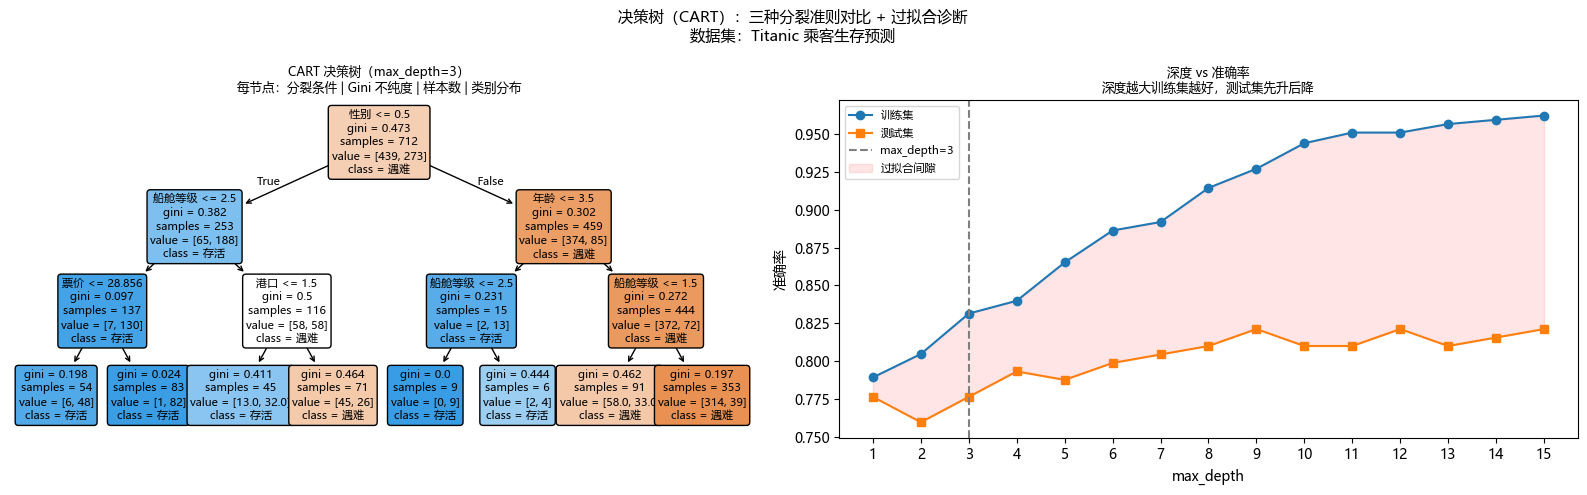

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ════════════════════════════════════════════════════════════════════
#  第一部分：根节点特征选择 —— ID3 / C4.5 / CART 三种算法对比
#
#  核心问题：对于根节点（第一次分裂），三种算法会各自选择哪个特征？
#  方法：手动计算每个特征在三种准则下的得分，最高分的特征即被选中
# ════════════════════════════════════════════════════════════════════

# ── 数据准备 ─────────────────────────────────────────────────────
raw = sns.load_dataset('titanic')
# 只保留 6 列：目标变量 survived + 5 个特征
df = raw[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].copy()

# 填充缺失值
df['age']      = df['age'].fillna(df['age'].median())   # age 有 177 个缺失，用中位数填
df['embarked'] = df['embarked'].fillna('S')             # embarked 只有 2 个缺失，用众数 'S' 填

# OrdinalEncoder 把字符串类别转成整数（决策树只接受数值输入）
# sex:      female → 0，male → 1
# embarked: C → 0，Q → 1，S → 2
df[['sex', 'embarked']] = OrdinalEncoder().fit_transform(df[['sex', 'embarked']])

y = df['survived'].values   # 标签数组：1=存活，0=遇难，共 891 个

# 特征列表：(列名, 中文名, 是否为连续特征)
# 连续特征（age/fare）需要枚举阈值做二分；离散特征（pclass/sex/embarked）可以直接按取值分组
features = [
    ('pclass',   '船舱等级', False),   # 3 个取值：1/2/3
    ('sex',      '性别',     False),   # 2 个取值：0(female)/1(male)
    ('age',      '年龄',     True),    # 连续值，需枚举切分点
    ('fare',     '票价',     True),    # 连续值，需枚举切分点
    ('embarked', '港口',     False),   # 3 个取值：0/1/2
]

# ── 三种准则的数学工具函数 ────────────────────────────────────

def H(y):
    """
    香农熵（Shannon Entropy）—— ID3 / C4.5 的纯度度量
    
    公式：H(S) = -Σ P(c) · log₂P(c)
    
    直觉：
      - 节点越"纯"（所有样本同类），熵越低（趋近 0）
      - 节点越"乱"（各类均匀分布），熵越高（二分类最大值 = 1.0）
    
    二分类简化：只需知道正类比例 p，负类比例自动为 1-p
      H = -(p·log₂p + (1-p)·log₂(1-p))
    """
    p = np.mean(y)                                          # 存活比例（正类比例）
    if p <= 0 or p >= 1: return 0.0                        # 纯节点：熵为 0
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

def Gini(y):
    """
    Gini 不纯度（Gini Impurity）—— CART 的纯度度量
    
    公式：Gini(S) = 1 - Σ P(c)²
    
    直觉：
      - 随机从节点取两个样本，两个样本类别不同的概率
      - 节点越纯，这个概率越低，Gini 越小（趋近 0）
      - 二分类最大值 = 0.5（各占 50% 时）
    
    二分类简化：Gini = 1 - (p² + (1-p)²) = 2p(1-p)
    """
    p = np.mean(y)
    return 2 * p * (1 - p)                                 # 二分类简化公式

def split_info(probs):
    """
    分裂信息量（Split Information / Intrinsic Value）—— C4.5 专用
    
    公式：IV(A) = -Σ |Sᵢ|/|S| · log₂(|Sᵢ|/|S|)
    
    作用：惩罚分支数多的特征，避免 ID3 偏好取值多的特征（如"样本ID"）
    
    直觉：
      - 把当前特征的分布本身当作一个"熵"来计算
      - 分支越多、越均匀 → IV 越大 → 增益率 GR = IG/IV 越小
      - 这样取值多的特征会被自动压低评分
    
    probs: 各子集的占比列表，如 [0.3, 0.7] 表示二分后左子集占30%、右子集占70%
    """
    return -sum(p * np.log2(p) for p in probs if p > 1e-12)   # 过滤掉 p=0 避免 log(0)

def best_binary(x, y, fn):
    """
    枚举所有可能的二分阈值，找到使「fn 减少量」最大的阈值
    
    用于连续特征（age、fare）和 CART 对离散特征的二分处理。
    
    CART 的核心设计之一：无论特征是连续还是离散，始终只做「二叉分裂」
    （而 ID3 对多值离散特征会做多路分裂，树可能变得很宽）
    
    阈值候选集：相邻两个不同取值的均值（即可能的最优切分点就在这些均值附近）
    例如 age 的取值有 [10, 20, 30, ...]，候选阈值就是 [15, 25, ...]
    
    参数：
      x:  特征列（一维数组）
      y:  标签列（一维数组）
      fn: 不纯度函数，传 H 则用于 ID3/C4.5，传 Gini 则用于 CART
    
    返回：(最优阈值 t, 对应的最大增益值)
    """
    uniq = np.sort(np.unique(x))                            # 所有不同取值，排序后才能生成相邻均值
    if len(uniq) < 2: return uniq[0], 0.0                  # 只有一个取值，无法分裂，增益为 0

    thresholds = (uniq[:-1] + uniq[1:]) / 2.0              # 相邻均值 = 候选阈值集合
    parent_impurity = fn(y)                                 # 分裂前父节点的不纯度
    best_t, best_g  = thresholds[0], -np.inf               # 初始化最优阈值和最大增益

    for t in thresholds:
        L, R = y[x <= t], y[x > t]                         # 按阈值 t 把样本分成左右两组
        if len(L) == 0 or len(R) == 0: continue            # 空节点无意义，跳过

        # 加权不纯度 = 左子集权重 × 左子集不纯度 + 右子集权重 × 右子集不纯度
        weighted = len(L)/len(y) * fn(L) + len(R)/len(y) * fn(R)
        gain = parent_impurity - weighted                   # 增益 = 父节点不纯度 - 分裂后加权不纯度

        if gain > best_g:
            best_g, best_t = gain, t                        # 更新最优

    return best_t, best_g

# ── 逐特征计算三种准则的得分 ──────────────────────────────────
print("=" * 74)
print("  根节点特征选择：ID3 (信息增益) / C4.5 (增益率) / CART (Gini 减少量)")
print("=" * 74)
print(f"\n  Titanic：{len(y)} 个样本，存活率 = {y.mean():.1%}")
print(f"  父节点  H(S)    = {H(y):.4f}   公式：H = -Σ P(c)·log₂P(c)")
print(f"  父节点  Gini(S) = {Gini(y):.4f}   公式：Gini = 1 - Σ P(c)²\n")

rows = []   # 汇总结果，格式：(中文名, 列名, IG, GR, ΔGini)

for feat, label, is_cont in features:
    x    = df[feat].values                  # 取出该特征的数据列
    uniq = np.sort(np.unique(x))            # 该特征的所有不同取值
    n    = len(y)                           # 总样本数（分母）

    print(f"  ── {label}（{feat}），{'连续特征' if is_cont else f'离散特征，{len(uniq)} 种取值'} ──")

    if is_cont:
        # ══════════════════════════════════════════════════════════
        # 连续特征处理策略：
        #   ID3 / C4.5：枚举阈值找使「信息增益」最大的切分点
        #   CART：      枚举阈值找使「Gini 减少量」最大的切分点
        # 注意：两者可能选出不同阈值（因为优化目标不同）
        # ══════════════════════════════════════════════════════════

        # ---- ID3 部分：最优二分阈值（按熵最小化）----
        t_e, ig  = best_binary(x, y, H)            # t_e = 最优阈值，ig = 最大信息增益
        L_e, R_e = y[x <= t_e], y[x > t_e]        # 按最优阈值分割后的左右子集标签
        wL, wR   = len(L_e)/n, len(R_e)/n          # 左右子集的样本占比（权重）

        # ---- C4.5 部分：在 ID3 的 IG 基础上除以 IV ----
        iv_val = split_info([wL, wR])              # 二分时只有 2 个子集，probs = [wL, wR]
        gr     = ig / iv_val if iv_val > 0 else 0.0   # 增益率 GR = IG / IV

        # ---- CART 部分：最优二分阈值（按 Gini 最小化）----
        t_g, gg  = best_binary(x, y, Gini)        # 独立搜索，和 ID3 的 t_e 可能不同
        L_g, R_g = y[x <= t_g], y[x > t_g]
        wLg, wRg = len(L_g)/n, len(R_g)/n

        # 打印逐步推导过程，方便对照公式验算
        print(f"    ID3  最优阈值 {feat} ≤ {t_e:.2f}：")
        print(f"         IG = H(S) − wL·H(L) − wR·H(R)")
        print(f"            = {H(y):.4f} − {wL:.3f}×{H(L_e):.4f} − {wR:.3f}×{H(R_e):.4f} = {ig:.4f}")
        print(f"    C4.5 IV  = −(wL·log₂wL + wR·log₂wR)   ← 分裂信息量，惩罚均匀二分")
        print(f"            = −({wL:.3f}·log₂{wL:.3f} + {wR:.3f}·log₂{wR:.3f}) = {iv_val:.4f}")
        print(f"         GR  = IG / IV = {ig:.4f} / {iv_val:.4f} = {gr:.4f}")
        print(f"    CART 最优阈值 {feat} ≤ {t_g:.2f}（可能与 ID3 阈值不同，因优化目标不同）：")
        print(f"         ΔGini = Gini(S) − wL·Gini(L) − wR·Gini(R)")
        print(f"               = {Gini(y):.4f} − {wLg:.3f}×{Gini(L_g):.4f} − {wRg:.3f}×{Gini(R_g):.4f} = {gg:.4f}")

    else:
        # ══════════════════════════════════════════════════════════
        # 离散特征处理策略（关键差异！）：
        #   ID3：多路分裂 —— 有几个取值就分成几个子集（可能分支数 > 2）
        #   C4.5：同 ID3 多路分裂，但增益率会惩罚分支多的特征
        #   CART：强制二叉分裂 —— 把取值分成两组，枚举最优分组方式
        # ══════════════════════════════════════════════════════════

        # ---- ID3 / C4.5 多路分裂部分 ----
        # 每个取值 v 对应一个子集，权重 = 该取值的样本数 / 总样本数
        counts  = np.array([np.sum(x == v) for v in uniq])   # 每个取值的样本数
        weights = counts / n                                    # 每个子集的权重
        subsets = [y[x == v] for v in uniq]                   # 每个子集的标签数组

        # 信息增益 IG = 父节点熵 - 各子集的加权熵之和
        ig = H(y) - sum(w * H(s) for w, s in zip(weights, subsets))

        # 分裂信息量 IV（多路分裂时分支多，IV 更大，会压低 GR）
        iv_val = split_info(weights)
        gr     = ig / iv_val if iv_val > 0 else 0.0

        # ---- CART 二叉分裂部分 ----
        # 对离散特征，CART 也只做二分：将取值分成「≤ 阈值」和「> 阈值」两组
        # 因为 OrdinalEncoder 编码后值是整数，这等价于把取值分成两个子集
        t_g, gg  = best_binary(x, y, Gini)
        L_g, R_g = y[x <= t_g], y[x > t_g]
        wLg, wRg = len(L_g)/n, len(R_g)/n
        left_vals  = [int(v) for v in uniq if v <= t_g]   # 编码后落在左边的取值
        right_vals = [int(v) for v in uniq if v >  t_g]   # 编码后落在右边的取值

        # 打印 ID3 多路分裂公式展开（显示每个子集的贡献）
        weighted_str = " + ".join(f"{w:.3f}×{H(s):.4f}" for w, s in zip(weights, subsets))
        print(f"    ID3  IG = H(S) − ( {weighted_str} )")
        print(f"            = {H(y):.4f} − {sum(w*H(s) for w,s in zip(weights,subsets)):.4f} = {ig:.4f}")

        # 打印 C4.5 IV 展开（显示每个分支的权重对 IV 的贡献）
        iv_str = " + ".join(f"{w:.3f}·log₂{w:.3f}" for w in weights)
        print(f"    C4.5 IV = −({iv_str}) = {iv_val:.4f}")
        print(f"         GR = IG / IV = {ig:.4f} / {iv_val:.4f} = {gr:.4f}")

        # 打印 CART 二叉分裂（显示编码值的分组方式）
        print(f"    CART 最优二分 {feat} ≤ {t_g:.1f}（编码值 {left_vals} vs {right_vals}）：")
        print(f"         ΔGini = {Gini(y):.4f} − {wLg:.3f}×{Gini(L_g):.4f} − {wRg:.3f}×{Gini(R_g):.4f} = {gg:.4f}")

    rows.append((label, feat, ig, gr, gg))    # 存入汇总列表
    print()

# ── 汇总对比表 ────────────────────────────────────────────────
print("=" * 74)
print(f"  {'特征':<14} {'ID3 信息增益':>14} {'C4.5 增益率':>13} {'CART ΔGini':>12}")
print("─" * 74)
for lbl, feat, ig, gr, gg in rows:
    print(f"  {lbl+'('+feat+')':<17} {ig:>13.4f} {gr:>13.4f} {gg:>12.4f}")
print("─" * 74)

# 找出每种准则下得分最高的特征（即根节点会被选中的特征）
b_id3  = max(rows, key=lambda r: r[2])    # IG 最大
b_c45  = max(rows, key=lambda r: r[3])    # GR 最大
b_cart = max(rows, key=lambda r: r[4])    # ΔGini 最大
print(f"\n  ★ ID3  根节点最优特征：{b_id3[0]}（IG    = {b_id3[2]:.4f}）")
print(f"  ★ C4.5 根节点最优特征：{b_c45[0]}（GR    = {b_c45[3]:.4f}）")
print(f"  ★ CART 根节点最优特征：{b_cart[0]}（ΔGini = {b_cart[4]:.4f}）")
if b_id3[1] == b_c45[1] == b_cart[1]:
    print(f"\n  → 三种算法在此数据集上均选「{b_id3[0]}」作为根节点首分裂特征")
else:
    print(f"\n  → 三种算法选择不同，体现了各准则对特征类型的偏好差异")
print(f"    提示：增益率 (GR) 会惩罚分支数多的特征（如港口 3 值 > 性别 2 值），")
print(f"          Gini 减少量无对数运算、计算更快，但三者的节点纯度直觉完全一致")

# ════════════════════════════════════════════════════════════════════
#  第二部分：sklearn CART 实战 —— 过拟合诊断
#
#  sklearn 的 DecisionTreeClassifier 内部使用 CART（criterion='gini'），
#  始终做二叉分裂，本部分演示 max_depth 对过拟合的控制作用
# ════════════════════════════════════════════════════════════════════

feat_names = ['船舱等级', '性别', '年龄', '票价', '港口']
X = df.drop('survived', axis=1).values                          # 特征矩阵，形状 (891, 5)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y            # stratify 保持训练/测试集的类别比例一致
)

# 训练两棵树：一棵不限深度（会过拟合），一棵限制到 3 层（泛化更好）
dt_deep    = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

print("\n" + "=" * 74)
print("  sklearn CART（criterion='gini'，二叉分裂）")
print("=" * 74)
for name, model in [('无限深度（过拟合）', dt_deep), ('max_depth=3（剪枝）', dt_shallow)]:
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    print(f"  {name:<18}  训练={tr:.3f}  测试={te:.3f}  差距={tr-te:.3f}")
print()
print("  → 深树训练集接近完美，但把噪声也「记住」了，测试集反而更差")
print("    max_depth=3 限制生长（即剪枝），泛化能力更强")

# ── 可视化：树结构 + 过拟合曲线 ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 左图：打印 max_depth=3 的完整树结构
# filled=True：按多数类着色（蓝=存活，橙=遇难），颜色越深表示节点越纯
# impurity=True：在每个节点显示 Gini 值，可直观看到分裂后纯度提升
plot_tree(dt_shallow, ax=axes[0],
          feature_names=feat_names, class_names=['遇难', '存活'],
          filled=True, fontsize=8, impurity=True, rounded=True)
axes[0].set_title(
    'CART 决策树（max_depth=3）\n每节点：分裂条件 | Gini 不纯度 | 样本数 | 类别分布',
    fontsize=9
)

# 右图：扫描 depth=1~15，画出训练/测试准确率随深度的变化曲线
# 这张图完美展示了「偏差-方差权衡」：
#   - 深度太小（左侧）：欠拟合，训练和测试都差
#   - 深度太大（右侧）：过拟合，训练好但测试下降
#   - 最优深度在曲线的「拐点」附近
depths = range(1, 16)
train_accs, test_accs = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  m.predict(X_test)))

axes[1].plot(depths, train_accs, 'o-', label='训练集', color='C0')
axes[1].plot(depths, test_accs,  's-', label='测试集',  color='C1')
axes[1].axvline(3, color='gray', linestyle='--', lw=1.5, label='max_depth=3')
axes[1].fill_between(depths, train_accs, test_accs,
                     alpha=0.1, color='red', label='过拟合间隙')   # 红色填充区域 = 过拟合程度
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('准确率')
axes[1].set_title('深度 vs 准确率\n深度越大训练集越好，测试集先升后降', fontsize=9)
axes[1].legend(fontsize=8)
axes[1].set_xticks(list(depths))

plt.suptitle(
    '决策树（CART）：三种分裂准则对比 + 过拟合诊断\n数据集：Titanic 乘客生存预测',
    fontsize=11
)
plt.tight_layout()
plt.show()


### Bagging 集成（随机森林）

单棵决策树容易过拟合——深度无限制时，它会把训练集的每个噪声都"记住"。随机森林的思路是：**训练很多棵互不相同的树，用它们的集体投票代替单棵树的判断**。

两个"随机"的来源：
- **行采样（Bootstrap）**：每棵树只看训练集的一个随机子集（约 63%，有放回抽样）
- **列采样**：每次分裂时只从随机选取的一部分特征中挑最优切分点

两个随机让每棵树都"犯不同的错误"，投票之后错误相互抵消，整体泛化能力显著提升。这种「有放回抽样训练多个模型再集成」的策略叫做 **Bagging（Bootstrap Aggregating）**，随机森林是 Bagging 最经典的实现。

| | Bagging | 随机森林 |
|--|---------|----------|
| 基学习器 | 任意模型（决策树、SVM 等均可） | 只用决策树 |
| 列采样时机 | 每棵树采样一次（整棵树用固定的列子集） | **每个节点**采样一次（每次分裂重新随机选列） |
| 树的深度 | 通常剪枝，限制深度 | 通常**不剪枝**，长到最深 |
| 树间多样性 | 中（仅靠行采样制造差异） | 高（行采样 + 更激进的列采样） |

随机森林是 Bagging 的特化版本：通过"每节点列采样 + 深树"把树间去相关做到极致，强迫每棵树在不同特征子集上寻找最优分裂，使错误不再集中在同一强特征上。

- `n_estimators`：树的数量，越多越稳定，但有收益递减，通常 100~500 足够
- 每棵树的预测**并行**计算，可利用多核加速

### Boosting 集成

随机森林是**并行**训练一堆独立的树；Boosting 是**串行**训练，每棵新树专门拟合上一轮的**残差**（预测误差），一轮一轮地把错误修正掉。

```
第1棵树：预测结果，误差 = 真实值 - 预测值
第2棵树：专门学第1棵树的误差
第3棵树：专门学前两棵树加起来之后的剩余误差
……
最终预测 = 所有树的预测值加权求和
```

#### AdaBoost（1996）

- **纠错方式**：每轮训练后，把**分错的样本权重调高**，下一棵树重点学这些难样本
- 弱学习器通常是深度 = 1 的**树桩（stump）**
- 最终预测 = 各棵树的**加权投票**（准确率高的树权重大）
- **缺点**：对噪声和离群点敏感，难样本权重不断放大可能导致过拟合噪声

#### GBDT / Gradient Boosting（2001）

- **纠错方式**：每棵新树直接拟合**损失函数的负梯度（即残差）**
- 可以优化任意可微的损失函数（MSE、交叉熵等），比 AdaBoost 更通用
- sklearn 的 `GradientBoostingClassifier` 是经典 GBDT 实现
- **缺点**：原版实现较慢，树只能串行构建，大数据集耗时长

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score

# ── 数据准备 ──────────────────────────────────────────────────
raw = sns.load_dataset('titanic')
df_ml = raw[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()

df_ml['age']      = df_ml['age'].fillna(df_ml['age'].median())
df_ml['embarked'] = df_ml['embarked'].fillna(df_ml['embarked'].mode()[0])
df_ml['sex']      = OrdinalEncoder().fit_transform(df_ml[['sex']])
df_ml['embarked'] = OrdinalEncoder().fit_transform(df_ml[['embarked']])

feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df_ml[feature_cols].values
y = df_ml['survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 定义 4 个模型（随机森林开启 oob_score）────────────────────
models = {
    '浅树(depth=3)':      DecisionTreeClassifier(max_depth=3, random_state=42),
    '深树(无限深度)':     DecisionTreeClassifier(random_state=42),
    '随机森林(Bagging)':  RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42, n_jobs=-1),
    'AdaBoost(Boosting)': AdaBoostClassifier(n_estimators=100, random_state=42),
}

cv_all = {}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1', n_jobs=-1)
    cv_all[name] = cv_scores
    results[name] = {
        '训练准确率': accuracy_score(y_train, model.predict(X_train)),
        '测试准确率': accuracy_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred, pos_label=1),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
        'CV_F1均值': cv_scores.mean(),
        'CV_F1标准差': cv_scores.std(),
    }

# ── 结果汇总表 ────────────────────────────────────────────────
model_names = list(results.keys())
metric_keys = ['训练准确率', '测试准确率', 'F1', 'Recall', 'ROC-AUC', 'CV_F1均值', 'CV_F1标准差']

pd.set_option('display.unicode.east_asian_width', True)
df_res = pd.DataFrame(
    {k: [results[n][k] for n in model_names] for k in metric_keys},
    index=model_names
).round(3)

print("=" * 72)
print("  集成学习对比：Titanic 生存预测")
print(f"  训练集：{len(X_train)} 样本  测试集：{len(X_test)} 样本  存活率：{y_train.mean():.1%}")
print("=" * 72)
print(df_res.to_string())

rf_model = models['随机森林(Bagging)']
print(f"\n  随机森林 OOB score = {rf_model.oob_score_:.3f}")
print(f"  （每个样本只由没见过它的树预测，是随机森林真正的无偏泛化估计）")

# ── 结果解读 ──────────────────────────────────────────────────
rf  = results['随机森林(Bagging)']
ada = results['AdaBoost(Boosting)']
dt3 = results['浅树(depth=3)']
dtd = results['深树(无限深度)']

print("\n=== 结果解读 ===\n")

print("【1. 过拟合诊断】")
print(f"  深树：训练={dtd['训练准确率']:.3f} → 测试={dtd['测试准确率']:.3f}，差距明显，是过拟合的典型形态")
print(f"  随机森林：训练准确率同样接近 1.0，但不能说明它过拟合。")
print(f"  原因：预测训练集时每个样本被'见过它的树'投票，天然偏高。")
print(f"  OOB score = {rf_model.oob_score_:.3f} 与测试准确率接近，说明泛化正常，没有过拟合。\n")

print("【2. 随机森林 vs AdaBoost：哪个更好？】")
print(f"  测试准确率：随机森林={rf['测试准确率']:.3f}  AdaBoost={ada['测试准确率']:.3f}")
print(f"  F1         ：随机森林={rf['F1']:.3f}         AdaBoost={ada['F1']:.3f}")
print(f"  Recall     ：随机森林={rf['Recall']:.3f}     AdaBoost={ada['Recall']:.3f}")
print(f"  ROC-AUC    ：随机森林={rf['ROC-AUC']:.3f}    AdaBoost={ada['ROC-AUC']:.3f}")
print(f"  CV F1 均值 ：随机森林={rf['CV_F1均值']:.3f}  AdaBoost={ada['CV_F1均值']:.3f}")
print(f"  CV F1 标准差：随机森林={rf['CV_F1标准差']:.3f} AdaBoost={ada['CV_F1标准差']:.3f}")
print()

# 动态判断哪个更好
rf_win  = sum([rf[k] > ada[k] for k in ['测试准确率', 'F1', 'Recall', 'ROC-AUC', 'CV_F1均值']])
ada_win = sum([ada[k] > rf[k] for k in ['测试准确率', 'F1', 'Recall', 'ROC-AUC', 'CV_F1均值']])

print(f"  → 在 5 项指标中，随机森林领先 {rf_win} 项，AdaBoost 领先 {ada_win} 项")
print(f"  → CV F1 标准差：随机森林={'更小，稳定性更好' if rf['CV_F1标准差'] < ada['CV_F1标准差'] else '更大'}")
print()
print("  两者的本质差异：")
print("  随机森林靠'多棵独立深树平均'降低方差，对噪声不敏感，稳定性强")
print("  AdaBoost 靠'逐步纠错'降低偏差，在干净数据上精度高，但对噪声更敏感")
print("  Titanic 数据集噪声较多（年龄缺失、票价离群），这解释了两者表现差异的来源\n")

print("【3. CV F1 标准差：稳定性对比】")
for name in model_names:
    print(f"  {name:<22} CV F1 标准差 = {cv_all[name].std():.3f}")
print("  → 标准差越小说明模型对数据划分不敏感，泛化更可靠")
print("    深树标准差通常最大，随机森林最小，集成的意义在此体现")

  集成学习对比：Titanic 生存预测
  训练集：712 样本  测试集：179 样本  存活率：38.3%
                    训练准确率  测试准确率     F1  Recall  ROC-AUC  CV_F1均值  CV_F1标准差
浅树(depth=3)            0.833       0.793  0.673   0.551    0.818      0.726        0.042
深树(无限深度)           0.982       0.832  0.776   0.754    0.811      0.708        0.051
随机森林(Bagging)        0.982       0.827  0.763   0.725    0.828      0.746        0.050
AdaBoost(Boosting)       0.829       0.782  0.698   0.652    0.825      0.725        0.035

  随机森林 OOB score = 0.803
  （每个样本只由没见过它的树预测，是随机森林真正的无偏泛化估计）

=== 结果解读 ===

【1. 过拟合诊断】
  深树：训练=0.982 → 测试=0.832，差距明显，是过拟合的典型形态
  随机森林：训练准确率同样接近 1.0，但不能说明它过拟合。
  原因：预测训练集时每个样本被'见过它的树'投票，天然偏高。
  OOB score = 0.803 与测试准确率接近，说明泛化正常，没有过拟合。

【2. 随机森林 vs AdaBoost：哪个更好？】
  测试准确率：随机森林=0.827  AdaBoost=0.782
  F1         ：随机森林=0.763         AdaBoost=0.698
  Recall     ：随机森林=0.725     AdaBoost=0.652
  ROC-AUC    ：随机森林=0.828    AdaBoost=0.825
  CV F1 均值 ：随机森林=0.746  AdaBoost=0.725
  CV F1 标准差：随机森林=0.050 AdaBoost=0.035

  → 

## 2.7 K 近邻（KNN）

KNN 是最直觉的分类算法——**预测一个样本的类别，就看它周围 K 个最近邻居多数属于哪类**。没有显式的训练过程，所有计算都延迟到预测时发生，这种策略叫做**懒惰学习（Lazy Learning）**。

```
预测步骤：
1. 计算新样本与所有训练样本的距离
2. 找出距离最近的 K 个样本
3. 分类：K 个邻居中多数票属于哪类，预测就归哪类
   回归：K 个邻居目标值取平均
```

---

### K 值的影响

K 是 KNN 最关键的超参数，直接控制偏差-方差权衡：

| K 值 | 决策边界 | 行为 |
|------|---------|------|
| **K=1** | 极不规则 | 每个训练样本单独划一块区域，极易过拟合噪声 |
| **K 较小** | 复杂、锯齿状 | 局部细节敏感，方差大 |
| **K 较大** | 平滑 | 趋向全局多数类，偏差增大 |
| **K=全部样本数** | 退化为全局多数类 | 完全欠拟合 |

> 通常用交叉验证在 K=3~20 之间搜索最优值，选择测试误差最低的 K。

---

### 距离度量

KNN 的性能依赖于"距离"的定义：

- **欧氏距离**（默认）：直线距离 $d = \sqrt{\sum(x_i - x_i')^2}$，最常用
- **曼哈顿距离**：格子距离 $d = \sum|x_i - x_i'|$，对离群点更鲁棒
- **余弦相似度**：衡量方向而非距离，适合文本特征（两篇文章主题相似但词频绝对值不同）

> **必须标准化**：欧氏距离对量纲极度敏感。若特征包含"年龄（0\~80）"和"收入（0\~100000）"，收入的差值会完全压制年龄的贡献，年龄信息被淹没。使用前必须用 `StandardScaler` 统一量纲。

---

### 优缺点

**优点：**
- 原理极简，无需训练，新增数据只需加入数据集即可
- 不做任何分布假设，天然适应非线性、非凸的复杂边界
- 对异常类别分布也能工作（不像线性模型假设决策边界是直线）

**缺点：**
- **预测慢**：每次预测需遍历全部训练数据，数据量大时不可接受
- **内存消耗大**：必须把所有训练数据常驻内存，无法压缩成参数
- **维度诅咒（Curse of Dimensionality）**：高维空间中所有样本之间的距离趋于相等，"近邻"失去意义——100 维空间中，最近邻和最远邻的距离差几乎为零
- **特征冗余有害**：无关特征直接污染距离计算，必须提前做特征筛选

---

### 适用场景

✅ **适合：**
- 小/中规模数据集（通常 < 10 万样本）
- 特征维度不高且已经过筛选（< 50 维）
- 快速建立 baseline，不想写复杂的训练逻辑
- 推荐系统的近邻召回（基于用户/物品相似度）
- 异常检测（正常样本密集，异常点的 K 近邻距离会明显偏大）

❌ **不适合：**
- 大数据集（预测延迟不可接受）
- 高维稀疏特征（文本、图像原始像素）——维度诅咒直接失效
- 实时在线预测（无训练阶段的"优势"在推理时变成负担）
- 特征量纲差异悬殊且无法标准化的场景

## 2.8 支持向量机（SVM）

SVM 的目标是找到一个**间隔最大化**的超平面来分隔两类数据。与逻辑回归不同，SVM 只关心边界附近的少数样本（支持向量），边界以外的点不影响模型——这是 SVM 的根本特征。

---

### 为什么需要 SVM？从一个例子说起

假设你要用两个传感器指标（特征 x₁、x₂）识别机器**正常运行**和**故障**状态。采集到的数据如下：

- 正常状态：数据点散布在中间区域（中心圆）
- 故障状态：数据点分布在外围（外环）

这就是一个经典的**同心圆**分布，两类数据在原始 2D 空间中**无法被任何直线分开**。

用已学过的模型来试试：

**逻辑回归**：决策边界只能是直线，对这种数据完全失效，准确率接近随机猜测。

**决策树**：通过一系列"特征 ≤ 阈值"的横竖切割可以粗略逼近圆形边界，但需要大量分裂，边界是锯齿状的矩形拼合，泛化能力差，而且对圆心稍有偏移就可能失效。

**KNN**：能工作，但预测时要遍历所有训练点计算距离，数据量大时不可接受。

SVM 的做法完全不同：**不在原始 2D 空间里强行画边界，而是先把数据"升维"，在高维空间里找一个线性超平面，这个超平面映射回原始空间就自然成为一条曲线**。

对于同心圆问题，只需添加一个新维度 $z = x_1^2 + x_2^2$（到原点的距离的平方），数据就在 3D 空间中变成线性可分的——内圆的 $z$ 值小，外环的 $z$ 值大，一个水平超平面就能完美分开。

> 核函数（Kernel Trick）的作用：不需要真正计算 $z$ 坐标，只需在原始空间计算样本间的内积，就能等效地完成这个升维操作，避免了维度爆炸带来的计算量。

---

### 关键概念

**支持向量（Support Vectors）**
距离决策边界最近的那些样本点，超平面位置完全由它们决定。其余所有点如果位置稍作改变，都不会影响决策边界——这让 SVM 对远离边界的噪声有天然的鲁棒性。

**间隔（Margin）**
两侧支持向量到决策边界的距离之和，SVM 最大化这个值。间隔越大，模型对新样本的分类置信度越高，泛化能力越强。

参数 `C` 控制对误分类的容忍程度：C 大 → 间隔小、紧贴训练集 → 倾向过拟合；C 小 → 间隔大、边界平滑 → 倾向欠拟合。

---

### 核函数（Kernel Trick）

| 核函数 | 主要参数 | 适用场景 |
|--------|---------|---------|
| `linear` | C | 线性可分数据；高维稀疏特征（文本分类） |
| `rbf`（高斯核） | C, gamma | 最通用，适合大多数非线性问题，优先尝试 |
| `poly` | C, degree | 数据有多项式边界结构 |

> **gamma 参数**（仅 rbf/poly）：控制核函数的影响范围。gamma 大 → 每个训练点影响范围小 → 决策边界复杂 → 容易过拟合；gamma 小 → 影响范围大 → 决策边界平滑。

---

### 适用场景

✅ **适合：**
- 中小规模数据集（通常 < 10 万样本）
- **高维稀疏特征**：文本分类（TF-IDF 特征向量）、DNA 序列分类——这是 SVM 最擅长的场景
- **样本数量少但维度高**：样本稀缺时，最大化间隔的目标有助于防止过拟合

❌ **不适合：**
- 超大数据集（训练时间复杂度约 $O(n^2)$ 到 $O(n^3)$）
- 需要输出概率的场景——SVM 原生输出的是"到边界的距离"，不是概率
- 需要模型可解释性的场景

## 2.9 模型评估

训练好一个模型之后，怎么判断它"好不好"？不同任务的回答方式完全不同：分类模型关心"判断对了多少"，回归模型关心"预测值离真实值有多远"。本节系统介绍两类指标，并用 Titanic 数据集跑 6 个模型，得出哪类模型最适合这个任务。

---

## 分类评估

### 混淆矩阵（Confusion Matrix）

所有分类指标都从混淆矩阵派生。以 Titanic 生存预测为例，模型的每个预测结果落入四个格子之一：

```
                  预测：遇难（0）    预测：存活（1）
实际：遇难（0）       TN（真负）        FP（假正）
实际：存活（1）       FN（假负）        TP（真正）
```

- **TN（True Negative）**：预测遇难，实际也遇难 ✅
- **FP（False Positive）**：预测存活，实际遇难 ❌（误报）
- **FN（False Negative）**：预测遇难，实际存活 ❌（漏报）
- **TP（True Positive）**：预测存活，实际也存活 ✅

漏报（FN）和误报（FP）哪个代价更大，取决于业务场景，这正是需要多个指标的原因。

---

### Accuracy（准确率）

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

**整体预测正确的比例。**

⚠️ **类别不平衡时会严重误导**：Titanic 中遇难者占 62%，如果模型把所有人都预测为遇难，Accuracy = 62%，看起来还不错——但实际上模型对存活者的预测全部错误，完全没用。

---

### Precision（精确率）和 Recall（召回率）

$$\text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN}$$

两个指标从不同角度衡量"正类预测的质量"：

- **Precision**：预测为存活的人里，真正存活的比例 —— 衡量**预测的可信度**，FP 越少越好
- **Recall**：真正存活的人里，被模型找出来的比例 —— 衡量**覆盖的完整性**，FN 越少越好

**两者存在天然的权衡（Precision-Recall Tradeoff）**：

- 降低预测阈值（更宽松地预测"存活"）→ Recall 升高，Precision 下降
- 提高预测阈值（更保守地预测"存活"）→ Precision 升高，Recall 下降

> **业务类比**：
> - 癌症筛查：宁可误报（高 Recall），不能漏掉真正的患者（FN 代价极高）
> - 垃圾邮件过滤：宁可漏过几封垃圾邮件（低 Recall），也不能误删重要邮件（FP 代价极高）

---

### F1 Score

$$F1 = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Precision 和 Recall 的**调和平均**。只有两者都高，F1 才高——任何一个极低都会把 F1 拉下来，比算术平均更严苛。

当你不知道业务上哪个更重要时，F1 是最常用的单一指标。

---

### ROC-AUC

大多数分类模型输出的不是直接的类别，而是一个**概率值**（如 0.73，表示 73% 可能存活），再由用户设定阈值（默认 0.5）来决定最终类别。ROC 曲线展示了**在所有可能的阈值下**，模型 Recall 和误报率（FPR）的变化轨迹：

- X 轴：FPR（假正率）= FP / (FP + TN)，即遇难者被误判为存活的比例
- Y 轴：Recall（TPR），即存活者被正确召回的比例

**AUC（Area Under Curve）** 是 ROC 曲线下面积，范围 0~1：
- AUC = 1.0：完美分类，所有阈值下都能完全区分两类
- AUC = 0.5：和随机猜测一样差（对角线）
- AUC > 0.8：通常认为模型有较好的区分能力

AUC 的好处是**不依赖于阈值的选择**，衡量的是模型对两类的整体区分能力，而不是某个特定阈值下的表现。

---

## 回归评估

回归任务预测的是连续值，没有"对"和"错"之分，只有"差多少"的问题。

### MAE（平均绝对误差）

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

所有样本预测误差绝对值的平均。**单位和目标变量相同**（预测房价，MAE=10 万元）——直觉最强，业务可解释性最好。对离群点不敏感（绝对值而非平方，大误差不会被额外放大）。

### RMSE（均方根误差）

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

误差先平方再平均再开根号。**单位也和目标变量相同**，但比 MAE 更惩罚大误差——一个 10 倍的误差，在 RMSE 里的贡献是 100 倍。当你特别不希望出现离谱预测时，用 RMSE。

> MAE vs RMSE：如果数据有较多离群点，两者差距会明显；RMSE 大幅高于 MAE 意味着存在少量大误差。

### R²（决定系数）

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

衡量模型解释了目标变量**多少比例的方差**，范围通常在 0~1（负数意味着比直接取均值还差）：
- R² = 1：完美预测
- R² = 0：模型和"永远预测均值"一样，毫无信息量
- R² = 0.8：模型解释了 80% 的方差，还有 20% 无法解释

R² 的优势是**无量纲**，可以跨数据集比较模型好坏；MAE/RMSE 受目标变量量纲影响，跨数据集比较没有意义。

  6 个模型对比：Titanic 生存预测（测试集 179 样本）
             Accuracy  Precision  Recall     F1  ROC-AUC
逻辑回归        0.799      0.780   0.667  0.719    0.852
决策树(d=3)     0.793      0.864   0.551  0.673    0.818
随机森林        0.827      0.806   0.725  0.763    0.828
AdaBoost        0.782      0.750   0.652  0.698    0.825
KNN(k=7)        0.816      0.773   0.739  0.756    0.846
SVM(rbf)        0.816      0.833   0.652  0.732    0.838


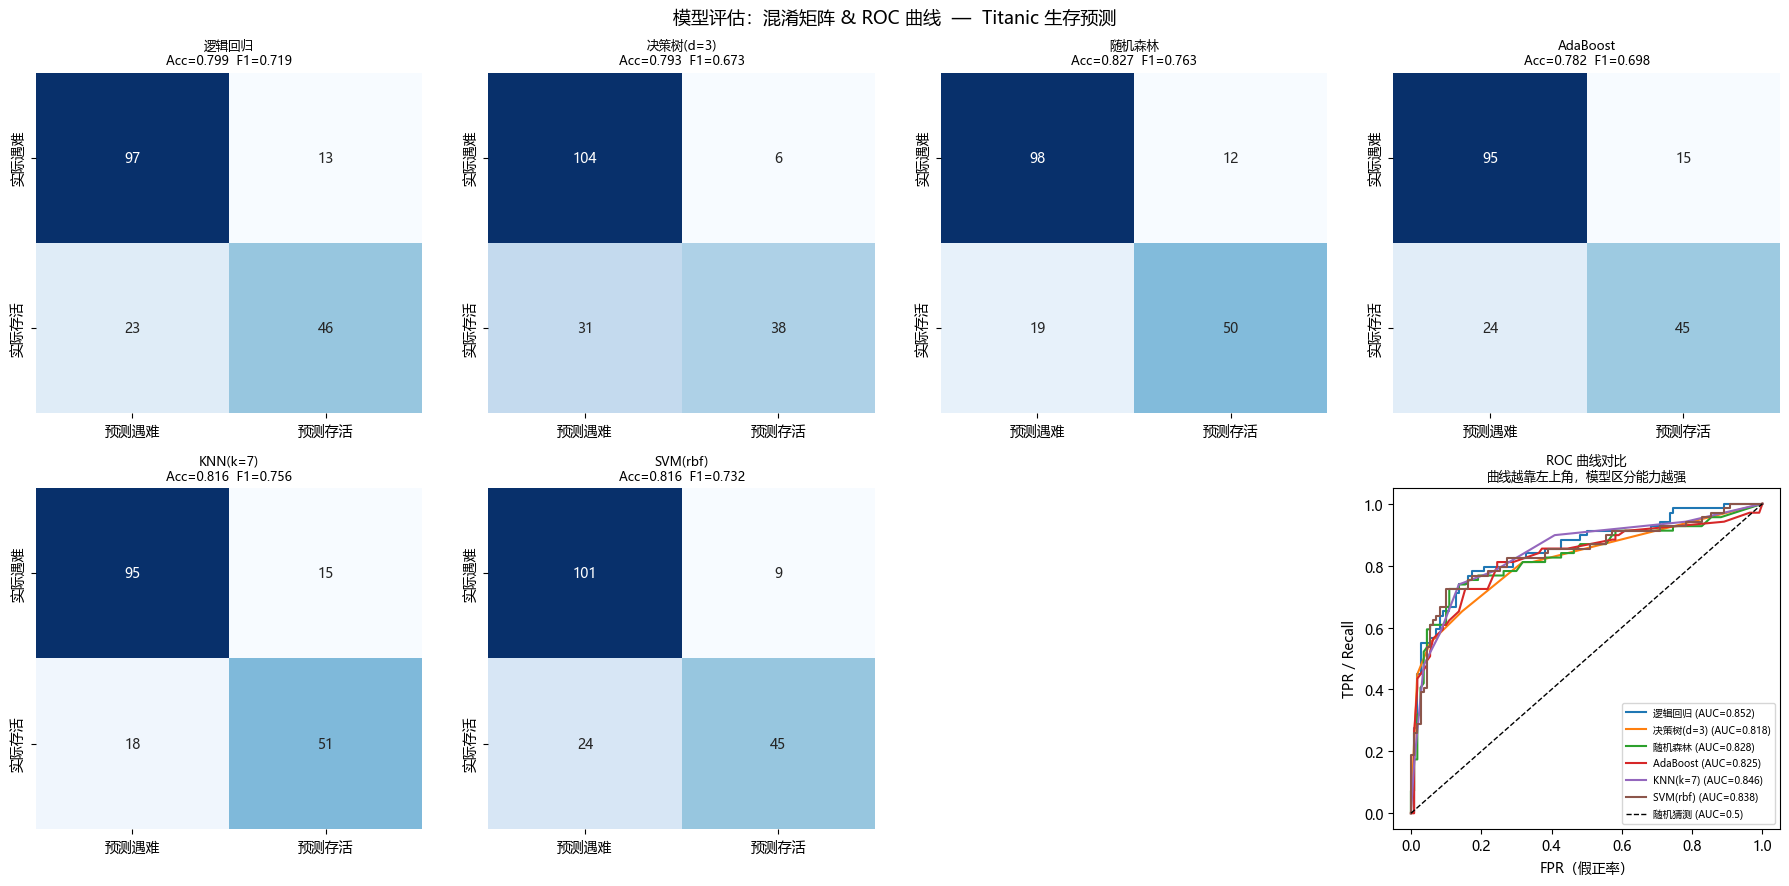


=== 结论分析 ===

  Accuracy   最高：随机森林（0.827）
  Precision  最高：决策树(d=3)（0.864）
  Recall     最高：KNN(k=7)（0.739）
  F1         最高：随机森林（0.763）
  ROC-AUC    最高：逻辑回归（0.852）

【为什么树模型和随机森林在 Titanic 上表现最好？】
  Titanic 的生存逻辑本质上是一套树状规则：
    性别=女性 → 大概率存活（'女士优先'原则）
    性别=男性 且 pclass=1 → 存活率明显高于三等舱男性
    年龄 < 15 → 儿童优先疏散，存活率较高
  这类阈值明确的规则，决策树天然擅长捕捉，不需要特征工程。

【逻辑回归为什么也不差？】
  性别、舱位这两个最强特征与存活结果有很强的线性相关性，
  逻辑回归能够直接利用这种相关性，所以 ROC-AUC 也很高。

【为什么 Accuracy 不够可信？】
  Titanic 存活率 38%，类别轻度不平衡。
  即使模型把全部人预测为遇难，Accuracy 也有 62%。
  应优先看 F1 和 ROC-AUC，这两个指标对类别不平衡更鲁棒。

  回归评估演示：用乘客特征预测票价（fare）


                 MAE    RMSE     R²
线性回归      20.837  30.470  0.400
Ridge回归     20.805  30.450  0.401
随机森林回归  15.094  41.167 -0.095

【指标解读】
  MAE：平均每个乘客的票价预测误差（单位：美元），直觉最强
  RMSE：比 MAE 更惩罚大误差——Titanic 票价有离群高价票，RMSE 明显高于 MAE
  R²：模型解释了票价方差的比例，越接近 1 越好

  → 随机森林回归 R² 最高，因为票价与舱位、港口有非线性关系；
    线性模型难以捕捉头等舱离群高价，RMSE 被少量极高票价拉大


In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ════════════════════════════════════════════════════════════════════
#  数据准备
# ════════════════════════════════════════════════════════════════════
raw = sns.load_dataset('titanic')
df = raw[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()
df['age']      = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df[['sex', 'embarked']] = OrdinalEncoder().fit_transform(df[['sex', 'embarked']])

feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[feature_cols].values
y = df['survived'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# KNN 和 SVM 需要标准化
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ════════════════════════════════════════════════════════════════════
#  第一部分：6 个分类模型对比
# ════════════════════════════════════════════════════════════════════
models = {
    '逻辑回归':   (LogisticRegression(max_iter=1000, random_state=42), X_train_s, X_test_s),
    '决策树(d=3)': (DecisionTreeClassifier(max_depth=3, random_state=42), X_train, X_test),
    '随机森林':   (RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), X_train, X_test),
    'AdaBoost':   (AdaBoostClassifier(n_estimators=100, random_state=42), X_train, X_test),
    'KNN(k=7)':   (KNeighborsClassifier(n_neighbors=7), X_train_s, X_test_s),
    'SVM(rbf)':   (SVC(kernel='rbf', probability=True, random_state=42), X_train_s, X_test_s),
}

results = {}
cms = {}
roc_data = {}

for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
    }
    cms[name]      = confusion_matrix(y_test, y_pred)
    fpr, tpr, _    = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr)

# ── 指标汇总表 ────────────────────────────────────────────────
df_res = pd.DataFrame(results).T.round(3)
print("=" * 65)
print("  6 个模型对比：Titanic 生存预测（测试集 179 样本）")
print("=" * 65)
print(df_res.to_string())

# ── 可视化：混淆矩阵 + ROC 曲线 ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('模型评估：混淆矩阵 & ROC 曲线  —  Titanic 生存预测', fontsize=13)

model_names = list(models.keys())
for i, name in enumerate(model_names):
    ax = axes[0][i] if i < 4 else axes[1][i - 4]
    sns.heatmap(
        cms[name], annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['预测遇难', '预测存活'],
        yticklabels=['实际遇难', '实际存活'],
        cbar=False
    )
    acc = results[name]['Accuracy']
    f1  = results[name]['F1']
    ax.set_title(f'{name}\nAcc={acc:.3f}  F1={f1:.3f}', fontsize=9)

# ROC 曲线画在最后一个格子
ax_roc = axes[1][3]
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
for (name, (fpr, tpr)), color in zip(roc_data.items(), colors):
    auc = results[name]['ROC-AUC']
    ax_roc.plot(fpr, tpr, color=color, lw=1.5, label=f'{name} (AUC={auc:.3f})')
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='随机猜测 (AUC=0.5)')
ax_roc.set_xlabel('FPR（假正率）')
ax_roc.set_ylabel('TPR / Recall')
ax_roc.set_title('ROC 曲线对比\n曲线越靠左上角，模型区分能力越强', fontsize=9)
ax_roc.legend(fontsize=7, loc='lower right')

# 隐藏多余的子图
axes[1][2].axis('off')

plt.tight_layout()
plt.show()

# ── 结论分析 ──────────────────────────────────────────────────
print("\n=== 结论分析 ===\n")

# 动态找出每个指标最高的模型
for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    best = df_res[metric].idxmax()
    val  = df_res[metric].max()
    print(f"  {metric:<10} 最高：{best}（{val:.3f}）")

print()
print("【为什么树模型和随机森林在 Titanic 上表现最好？】")
print("  Titanic 的生存逻辑本质上是一套树状规则：")
print("    性别=女性 → 大概率存活（'女士优先'原则）")
print("    性别=男性 且 pclass=1 → 存活率明显高于三等舱男性")
print("    年龄 < 15 → 儿童优先疏散，存活率较高")
print("  这类阈值明确的规则，决策树天然擅长捕捉，不需要特征工程。")
print()
print("【逻辑回归为什么也不差？】")
print("  性别、舱位这两个最强特征与存活结果有很强的线性相关性，")
print("  逻辑回归能够直接利用这种相关性，所以 ROC-AUC 也很高。")
print()
print("【为什么 Accuracy 不够可信？】")
print("  Titanic 存活率 38%，类别轻度不平衡。")
print("  即使模型把全部人预测为遇难，Accuracy 也有 62%。")
print(f"  应优先看 F1 和 ROC-AUC，这两个指标对类别不平衡更鲁棒。")

# ════════════════════════════════════════════════════════════════════
#  第二部分：回归评估指标演示（票价预测）
# ════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  回归评估演示：用乘客特征预测票价（fare）")
print("=" * 65)

df_reg = df.copy()
X_reg = df_reg[['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked']].values
y_reg = df_reg['fare'].values

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_models = {
    '线性回归':   LinearRegression(),
    'Ridge回归':  Ridge(alpha=1.0),
    '随机森林回归': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_tr_r, y_tr_r)
    y_pred = model.predict(X_te_r)
    mae  = mean_absolute_error(y_te_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te_r, y_pred))
    r2   = r2_score(y_te_r, y_pred)
    reg_results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}

df_reg_res = pd.DataFrame(reg_results).T.round(3)
print(df_reg_res.to_string())

print()
print("【指标解读】")
print("  MAE：平均每个乘客的票价预测误差（单位：美元），直觉最强")
print("  RMSE：比 MAE 更惩罚大误差——Titanic 票价有离群高价票，RMSE 明显高于 MAE")
print("  R²：模型解释了票价方差的比例，越接近 1 越好")
print()
print("  → 随机森林回归 R² 最高，因为票价与舱位、港口有非线性关系；")
print("    线性模型难以捕捉头等舱离群高价，RMSE 被少量极高票价拉大")